# Chapter 7 — Strategy Taxonomy: Where Edges Come From

A conceptual chapter. We define what an edge actually is, walk through the four
canonical families of intraday strategies (mean reversion / momentum / breakout
/ event-driven), and then look at one empirical hook: where on QQQ does
mean-reversion show up in the autocorrelation curve?

No new data — we reuse Ch6's QQQ minute parquet.


## §1 — Setup

Load Ch6's QQQ minute parquet, filter to RTH, build minute log returns. Zero
out the first bar of each session — there's no intraday return at the
session boundary.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CH6_CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CH6_CACHE / "qqq_1min.parquet")
# Convert UTC timestamps from the cache to ET so session boundaries line up.
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
# Encode each bar's clock time as minutes-from-midnight for cheap window filters.
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9 * 60 + 30, 16 * 60
# Keep only Regular Trading Hours; the half-open window mirrors how exchanges count bars.
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
# Re-index time as 0..389 within each RTH session for groupby/bucket logic later.
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
# Date label per session — used to group bars by trading day.
rth["session_date"] = rth.index.normalize()
# Intraday log returns: ln(close_t / close_{t-1}).
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
# First bar of each session has a return spanning the overnight gap; null it
# so within-session statistics aren't contaminated by overnight moves.
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan
print(f"RTH bars: {len(rth):,}  sessions: {rth['session_date'].nunique()}")


RTH bars: 95,318  sessions: 251


## §2 — Expectancy: the only operational definition of edge

Three hypothetical strategies. Expectancy per trade in *R*-units (where 1R is
the average loss size) = hit_rate × payoff − (1 − hit_rate) × 1.

In [2]:
rows = []
# Expectancy in R-units: E = p*W - (1-p)*L, with L=1 by R-multiple convention.
# Three illustrative profiles: balanced, high-hit-rate-small-payoff, low-hit-rate-large-payoff.
for hr, payoff in [(0.55, 0.9), (0.70, 0.3), (0.30, 3.0)]:
    e = hr * payoff - (1 - hr) * 1.0
    rows.append({"hit_rate": hr, "payoff": payoff, "expectancy_R": round(e, 4)})
pd.DataFrame(rows)


,hit_rate,payoff,expectancy_R
0,0.55,0.9,0.045
1,0.70,0.3,-0.090
2,0.30,3.0,0.200


High hit rate alone proves nothing — the (0.70, 0.30) strategy bleeds. The
(0.30, 3.0) strategy with a terrible hit rate is the strongest of the three.
Costs aren't subtracted yet; Ch12 makes that honest.

## §3 — Where mean-reversion lives: lag-k autocorrelation on QQQ

Pearson correlation between the minute return at time *t* and the minute return
at time *t + k*, computed within each session and averaged across sessions.
Within-session keeps the overnight gap from contaminating the estimate.

In [3]:
def autocorr_within_session(grouped, lag):
    """Mean lag-k autocorrelation across sessions, computed *within* each session
    (no cross-session pairs — the overnight gap doesn't belong in the lag)."""
    rs = []
    for _, s in grouped:
        s = s.dropna()
        # Need enough bars for a stable per-session correlation.
        if len(s) < lag + 30:
            continue
        # Pair each bar with the bar k steps later within the same session.
        a, b = s.iloc[:-lag].values, s.iloc[lag:].values
        # Skip degenerate sessions (all-zero returns) — corrcoef would be NaN.
        if a.std() == 0 or b.std() == 0:
            continue
        rs.append(np.corrcoef(a, b)[0, 1])
    return float(np.mean(rs)), len(rs)


In [4]:
LAGS = [1, 5, 15, 30, 60, 120]
# Pre-materialize the (date, returns) groups once so each lag reuses the same split.
grouped = list(rth.groupby("session_date")["log_ret"])
# Sweep a range of lags; sign tells you mean-reversion (negative) vs momentum (positive).
auto_all = {k: autocorr_within_session(grouped, k)[0] for k in LAGS}
pd.Series(auto_all, name="rho_qqq").to_frame()


,rho_qqq
1,-0.028168
5,-0.008731
15,-0.008911
30,-0.007757
60,-0.002115
120,0.004336


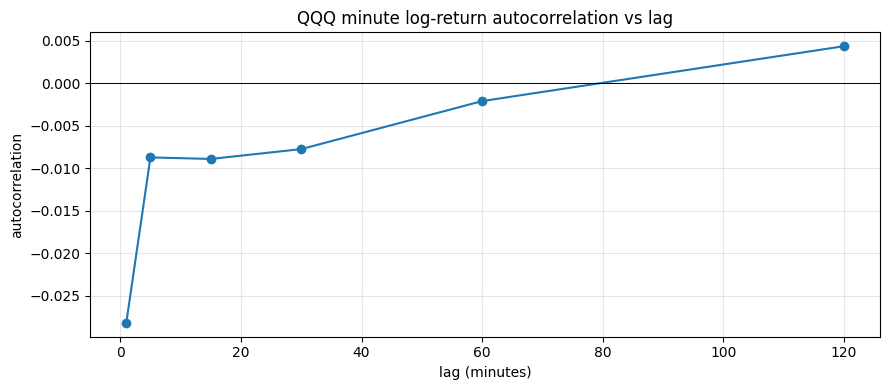

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(auto_all.keys()), list(auto_all.values()), marker="o")
ax.axhline(0, color="black", lw=0.7)
ax.set_xlabel("lag (minutes)")
ax.set_ylabel("autocorrelation")
ax.set_title("QQQ minute log-return autocorrelation vs lag")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Negative at lag 1 (~−0.028) → minute returns are anti-correlated; a positive
bar tends to be followed by a negative bar. That's mean-reversion: liquidity
providers fading overshoots. By lag 60 the effect is gone; by lag 120 it's
*slightly positive* — the early hint of trend continuation at longer
intraday horizons.

The lag where ρ is most negative is the horizon Ch8's first strategy will
target.

## §4 — Where in the session is mean-reversion cleanest?

Same lag-1 autocorrelation, split into three time-of-session buckets:
opening 30 min, midday (60-299), and closing 30 min.

In [6]:
def bucket_autocorr(df, mask, lag):
    """Same within-session lag-k autocorr as above, but on a boolean-masked subset
    of bars (e.g. only the opening 30 minutes)."""
    sub = df[mask]
    rs = []
    for _, s in sub.groupby("session_date")["log_ret"]:
        s = s.dropna()
        if len(s) < lag + 5:
            continue
        a, b = s.iloc[:-lag].values, s.iloc[lag:].values
        if a.std() == 0 or b.std() == 0:
            continue
        rs.append(np.corrcoef(a, b)[0, 1])
    return float(np.mean(rs)) if rs else float("nan"), len(rs)

# Three time-of-day buckets within an RTH session (0 = open, 389 = last RTH bar).
buckets = {
    "opening 30 min (0-29)":  rth["minute_of_session"].between(0, 29),
    "midday (60-299)":         rth["minute_of_session"].between(60, 299),
    "closing 30 min (360-389)": rth["minute_of_session"].between(360, 389),
}
pd.DataFrame(
    [{"bucket": name, "rho_lag1": round(bucket_autocorr(rth, mask, 1)[0], 5),
      "n_sessions": bucket_autocorr(rth, mask, 1)[1]}
     for name, mask in buckets.items()]
)


,bucket,rho_lag1,n_sessions
0,opening 30 min (0-29),-0.03513,251
1,midday (60-299),-0.03464,251
2,closing 30 min (360-389),-0.06684,248


**The closing 30 minutes is where mean-reversion is cleanest** — roughly 2×
the magnitude of opening or midday. This is the opposite of the textbook
story (which says midday is cleanest because it's quietest). The likely
explanation: closing-window activity is high (closing-auction flows, MOC
orders, index rebalances), and high activity + mechanical end-of-day flows
gives liquidity providers more overshoots to fade.

Ch8's first strategy harvests this window.

## §5 — Exercises

See the README for full prompts. Four exercises:

1. SPY lag-k autocorrelation — same shape as QQQ?
2. Expectancy arithmetic with cost subtraction
3. FOMC vs non-FOMC lag-1 autocorrelation
4. Identify the family — three prose strategy descriptions, name the family + mechanism
